# Lab 3

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

airbnb = pd.read_csv("airbnb_hw.csv")
cars   = pd.read_csv("cars_hw.csv")
pierce = pd.read_csv("pierce_county_house_sales.csv")

## 1

Host Id                          0
Host Since                       3
Name                             0
Neighbourhood                    0
Property Type                    3
Review Scores Rating (bin)    8193
Room Type                        0
Zipcode                        134
Beds                            83
Number of Records                0
Number Of Reviews                0
Price                            0
Review Scores Rating          8193
dtype: int64
            Host Id  Review Scores Rating (bin)       Zipcode          Beds  \
count  3.029700e+04                22104.000000  30163.000000  30214.000000   
mean   1.274428e+07                   90.731089  10586.805192      1.519329   
std    1.191552e+07                    9.056358    922.988153      0.983635   
min    5.000000e+02                   20.000000   1003.000000      0.000000   
25%    2.699261e+06                   85.000000  10017.000000      1.000000   
50%    8.530059e+06                   90.000000  10065.000

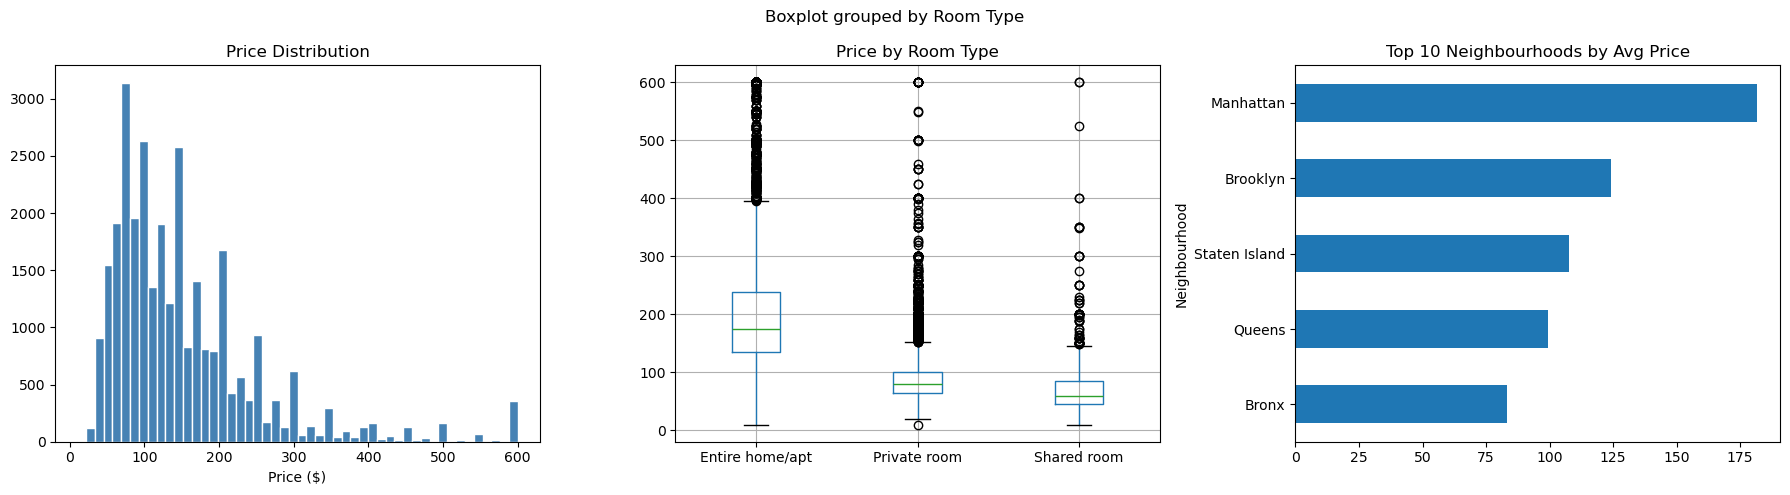

In [11]:
airbnb.columns = airbnb.columns.str.strip()
print(airbnb.isnull().sum())
airbnb["Price"] = pd.to_numeric(airbnb["Price"], errors="coerce")
airbnb = airbnb.dropna(subset=["Price", "Room Type", "Neighbourhood"])
airbnb["Price"] = airbnb["Price"].clip(upper=airbnb["Price"].quantile(0.99))

print(airbnb.describe())
print(airbnb["Room Type"].value_counts())
print(airbnb["Property Type"].value_counts().head(10))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(airbnb["Price"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Price Distribution")
axes[0].set_xlabel("Price ($)")
airbnb.boxplot(column="Price", by="Room Type", ax=axes[1])
axes[1].set_title("Price by Room Type")
axes[1].set_xlabel("")
airbnb.groupby("Neighbourhood")["Price"].mean().nlargest(10).sort_values().plot(
    kind="barh", ax=axes[2]
)
axes[2].set_title("Top 10 Neighbourhoods by Avg Price")

plt.tight_layout()
plt.show()

Make                 0
Make_Year            0
Color                0
Body_Type            0
Mileage_Run          0
No_of_Owners         0
Seating_Capacity     0
Fuel_Type            0
Transmission         0
Transmission_Type    0
Price                0
dtype: int64
         Make_Year   Mileage_Run  Seating_Capacity         Price
count   976.000000    976.000000        976.000000  9.760000e+02
mean   2016.963115  41571.195697          5.095287  7.397154e+05
std       2.818742  24390.995134          0.446224  3.615547e+05
min    2011.000000   1117.000000          4.000000  1.880000e+05
25%    2015.000000  22676.750000          5.000000  4.757500e+05
50%    2017.000000  37570.500000          5.000000  6.665000e+05
75%    2019.000000  57421.250000          5.000000  8.830000e+05
max    2022.000000  99495.000000          8.000000  1.978023e+06
Fuel_Type
petrol        783
diesel        191
petrol+cng      2
Name: count, dtype: int64
Transmission_Type
Manual       712
Automatic    264
Name: c

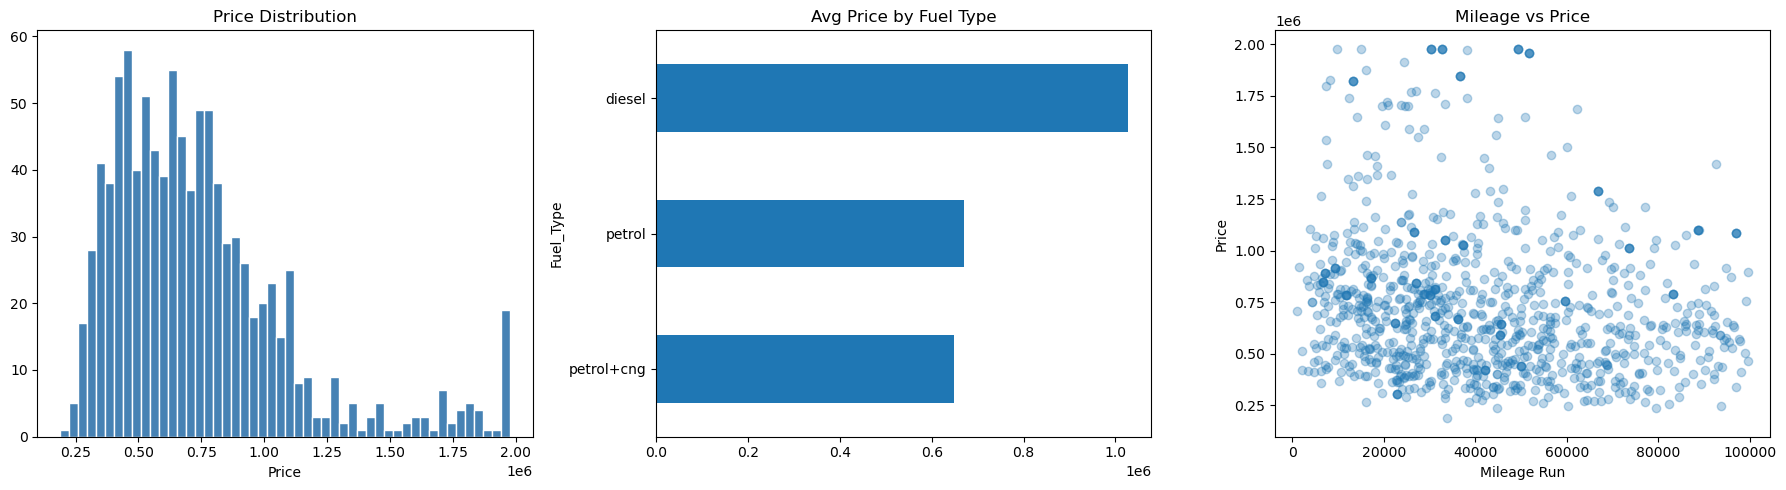

In [16]:
cars = cars.loc[:, ~cars.columns.str.startswith("Unnamed")]
print(cars.isnull().sum())
cars = cars.dropna()
cars["Price"] = cars["Price"].clip(upper=cars["Price"].quantile(0.99))

print(cars.describe())
print(cars["Fuel_Type"].value_counts())
print(cars["Transmission_Type"].value_counts())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(cars["Price"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Price Distribution")
axes[0].set_xlabel("Price")

cars.groupby("Fuel_Type")["Price"].mean().sort_values().plot(
    kind="barh", ax=axes[1]
)
axes[1].set_title("Avg Price by Fuel Type")

axes[2].scatter(cars["Mileage_Run"], cars["Price"], alpha=0.3)
axes[2].set_title("Mileage vs Price")
axes[2].set_xlabel("Mileage Run")
axes[2].set_ylabel("Price")

plt.tight_layout()
plt.show()


sale_date                          0
sale_price                         0
house_square_feet                  0
attic_finished_square_feet         0
basement_square_feet               0
attached_garage_square_feet        0
detached_garage_square_feet        0
fireplaces                         0
hvac_description                   7
exterior                           1
interior                           7
stories                            0
roof_cover                         8
year_built                         0
bedrooms                           0
bathrooms                          0
waterfront_type                16258
view_quality                   15891
utility_sewer                      0
sale_year                          0
sale_month                         0
dtype: int64
                           sale_date    sale_price  house_square_feet  \
count                          16810  1.681000e+04       16810.000000   
mean   2020-07-16 13:01:04.675788288  4.553053e+05        1879.9

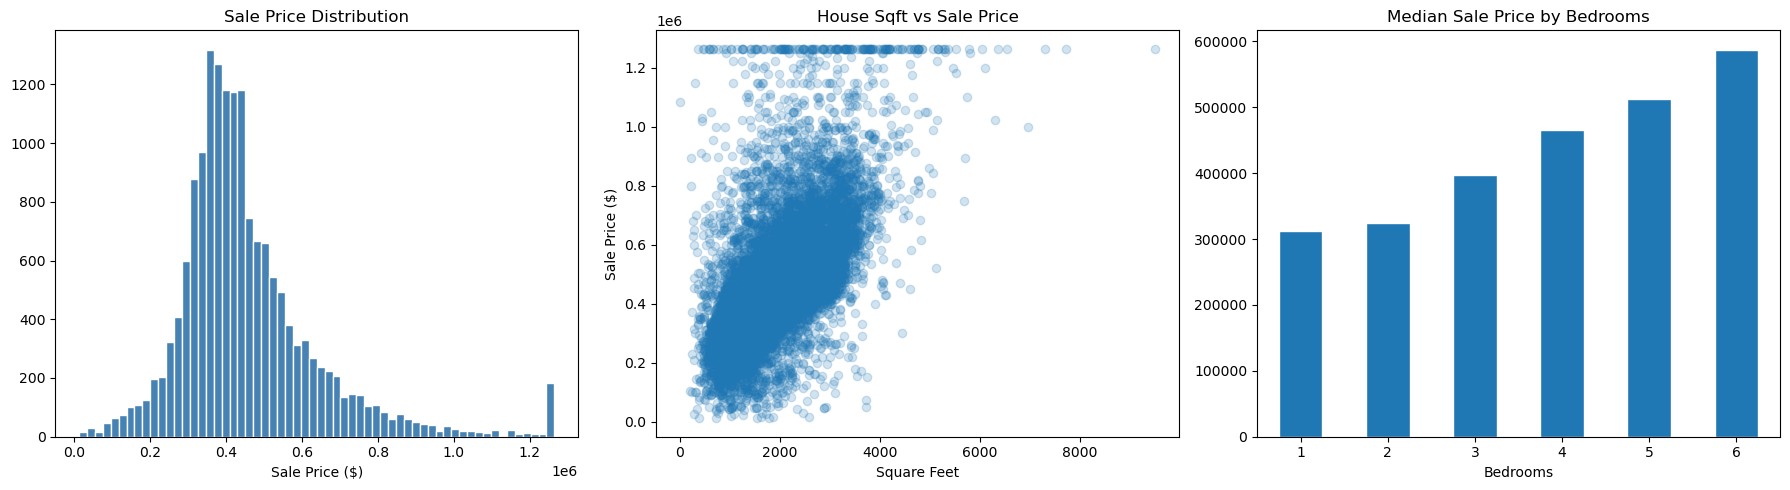

In [20]:
pierce["sale_date"] = pd.to_datetime(pierce["sale_date"])
pierce["sale_year"]  = pierce["sale_date"].dt.year
pierce["sale_month"] = pierce["sale_date"].dt.month

print(pierce.isnull().sum())
pierce = pierce.dropna(subset=["sale_price", "house_square_feet", "bedrooms", "bathrooms"])
pierce = pierce[pierce["sale_price"] > 10_000]                            
pierce["sale_price"] = pierce["sale_price"].clip(upper=pierce["sale_price"].quantile(0.99))

print(pierce.describe())
print(pierce["bedrooms"].value_counts().sort_index())
print(pierce["exterior"].value_counts().head(10))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(pierce["sale_price"], bins=60, color="steelblue", edgecolor="white")
axes[0].set_title("Sale Price Distribution")
axes[0].set_xlabel("Sale Price ($)")

axes[1].scatter(pierce["house_square_feet"], pierce["sale_price"], alpha=0.2)
axes[1].set_title("House Sqft vs Sale Price")
axes[1].set_xlabel("Square Feet")
axes[1].set_ylabel("Sale Price ($)")

pierce[pierce["bedrooms"].between(1, 6)].groupby("bedrooms")["sale_price"].median().plot(
    kind="bar", ax=axes[2], edgecolor="white"
)
axes[2].set_title("Median Sale Price by Bedrooms")
axes[2].set_xlabel("Bedrooms")
axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 2

In [37]:
airbnb = airbnb.drop(columns=["Host Id", "Host Since", "Name", "Zipcode"], errors="ignore")

owner_map = {"First": 1, "Second": 2, "Third": 3}
cars["No_of_Owners"] = cars["No_of_Owners"].map(owner_map)

pierce["sale_year"]  = pierce["sale_date"].dt.year
pierce["sale_month"] = pierce["sale_date"].dt.month
pierce = pierce.drop(columns=["sale_date"])

## 3

In [40]:
from sklearn.model_selection import train_test_split

airbnb_train, airbnb_test = train_test_split(airbnb, test_size=0.2, random_state=42)

cars_train, cars_test = train_test_split(cars, test_size=0.2, random_state=42)

pierce_train, pierce_test = train_test_split(pierce, test_size=0.2, random_state=42)

print(f"Airbnb: {len(airbnb_train)} train, {len(airbnb_test)} test")
print(f"Cars: {len(cars_train)} train, {len(cars_test)} test")
print(f"Pierce: {len(pierce_train)} train, {len(pierce_test)} test")

Airbnb: 24237 train, 6060 test
Cars: 780 train, 196 test
Pierce: 13448 train, 3362 test


## 4

In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score
import numpy as np

def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    results = {}
    for label, X, y in [("Train", X_train, y_train), ("Test", X_test, y_test)]:
        preds = model.predict(X)
        results[label] = {
            "RMSE": root_mean_squared_error(y, preds),
            "R2":   r2_score(y, preds)
        }
    return results

airbnb_features = [c for c in airbnb_train.columns if c != "Price"]
X_train_a = airbnb_train[airbnb_features].select_dtypes(include="number").fillna(0)
X_test_a  = airbnb_test[airbnb_features].select_dtypes(include="number").fillna(0)

airbnb_results = evaluate_model(LinearRegression(),
                                X_train_a, X_test_a,
                                airbnb_train["Price"], airbnb_test["Price"])

cars_features = [c for c in cars_train.columns if c != "Price"]
X_train_c = cars_train[cars_features].select_dtypes(include="number").fillna(0)
X_test_c  = cars_test[cars_features].select_dtypes(include="number").fillna(0)

cars_results = evaluate_model(LinearRegression(),
                              X_train_c, X_test_c,
                              cars_train["Price"], cars_test["Price"])

pierce_features = [c for c in pierce_train.columns if c != "sale_price"]
X_train_p = pierce_train[pierce_features].select_dtypes(include="number").fillna(0)
X_test_p  = pierce_test[pierce_features].select_dtypes(include="number").fillna(0)

pierce_results = evaluate_model(LinearRegression(),
                                X_train_p, X_test_p,
                                pierce_train["sale_price"], pierce_test["sale_price"])

for name, res in [("Airbnb", airbnb_results), ("Cars", cars_results), ("Pierce", pierce_results)]:
    print(f"{name}")
    for split, metrics in res.items():
        print(f"  {split}: RMSE={metrics['RMSE']:.2f}  R2={metrics['R2']:.4f}")

Airbnb
  Train: RMSE=90.54  R2=0.1868
  Test: RMSE=93.53  R2=0.1761
Cars
  Train: RMSE=301773.26  R2=0.3235
  Test: RMSE=282852.26  R2=0.2959
Pierce
  Train: RMSE=127672.34  R2=0.5291
  Test: RMSE=127669.59  R2=0.5401


Pierce County is the best model because it achieves an R2 of 0.53 on train and R2 of 0.54 test, meaning it explains about 53% of the variance in house sale prices. More importantly, its train and test metrics are nearly identical, which indicates the model is generalizing well with no overfitting.

## 5

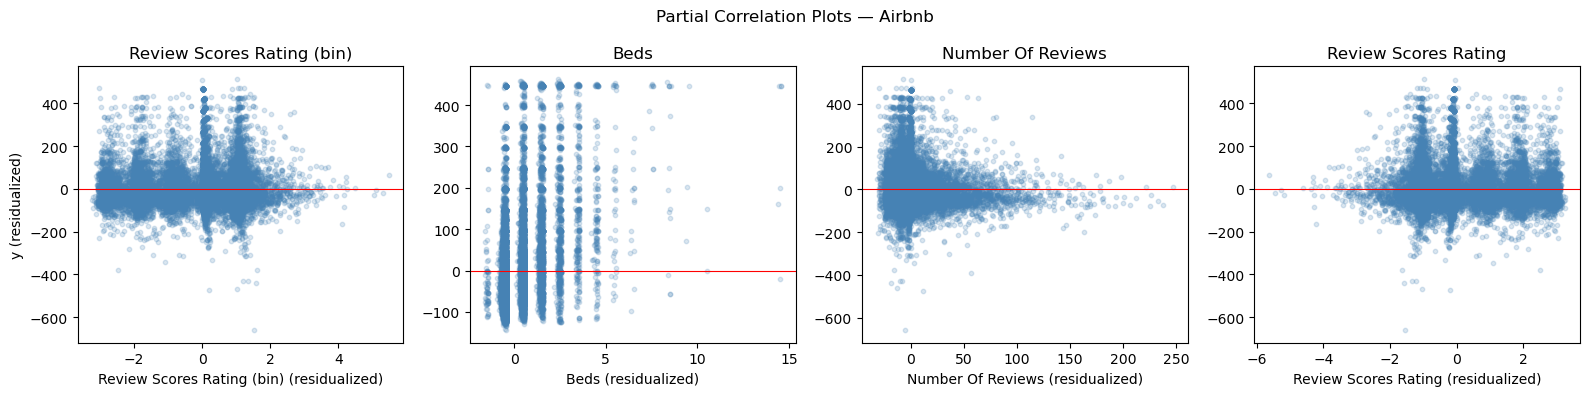

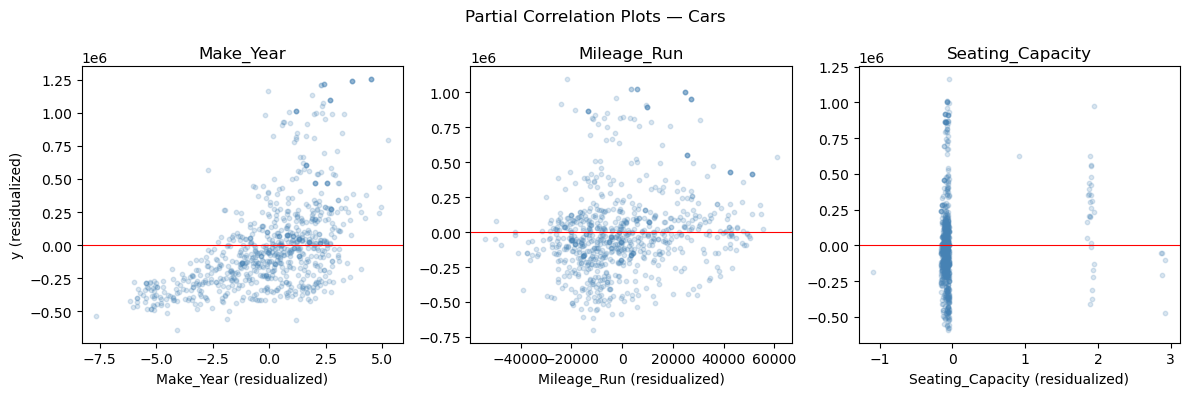

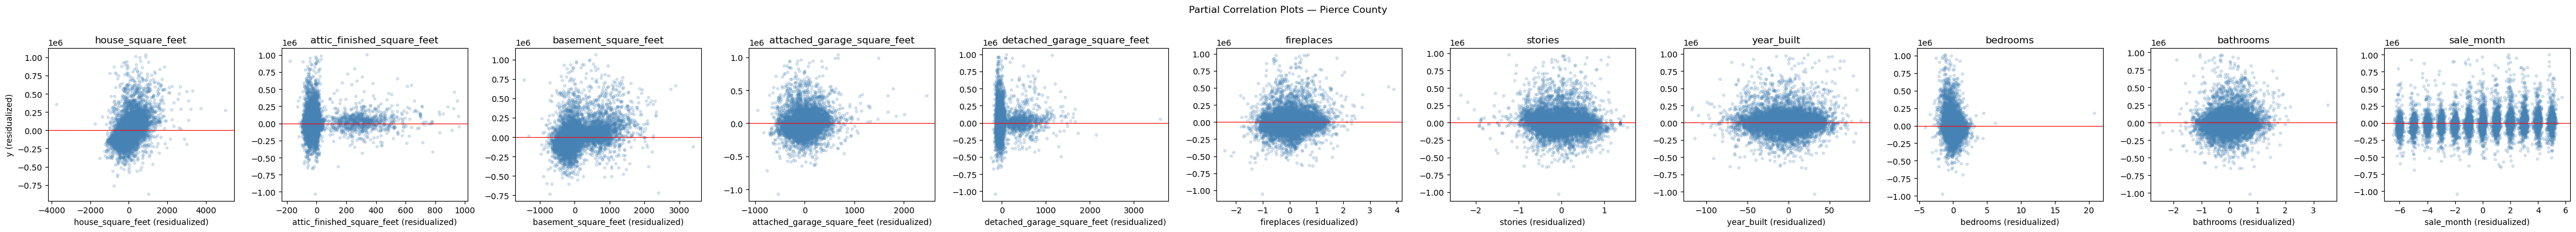

In [44]:
def partial_corr_plots(X_train, y_train, title):
    numeric_cols = X_train.select_dtypes(include="number").columns
    cols = [c for c in numeric_cols if X_train[c].nunique() > 2]
    
    n = len(cols)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    fig.suptitle(f"Partial Correlation Plots — {title}")
    
    for i, col in enumerate(cols):
        other = [c for c in numeric_cols if c != col]
        lr = LinearRegression()
        lr.fit(X_train[other], y_train)
        y_resid = y_train - lr.predict(X_train[other])
        
        lr2 = LinearRegression()
        lr2.fit(X_train[other], X_train[col])
        x_resid = X_train[col] - lr2.predict(X_train[other])
        
        axes[i].scatter(x_resid, y_resid, alpha=0.2, s=10, color="steelblue")
        axes[i].axhline(0, color="red", linewidth=0.8)
        axes[i].set_xlabel(f"{col} (residualized)")
        axes[i].set_ylabel("y (residualized)" if i == 0 else "")
        axes[i].set_title(col)
    
    plt.tight_layout()
    plt.show()

partial_corr_plots(X_train_a, airbnb_train["Price"], "Airbnb")
partial_corr_plots(X_train_c, cars_train["Price"], "Cars")
partial_corr_plots(X_train_p, pierce_train["sale_price"], "Pierce County")

In Airbnb, Review Scores Rating and Number of Reviews show non-linearity with minimal skew. In Cars, Mileage Run shows the most significant non-linearity with the points being more scattered everywhere. For Pierce County, a lot of the plots show non-linearity and the only plots that do show a trend are Attic Finished Square Feet and Detached Garage Square Feet.

## 6

In [45]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

y_train_a = np.log1p(airbnb_train["Price"])
y_test_a  = np.log1p(airbnb_test["Price"])

airbnb_complex = Pipeline([
    ("poly", PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)),
    ("lr",   LinearRegression())
])
airbnb_complex.fit(X_train_a, y_train_a)

for label, X, y_log, y_raw in [("Train", X_train_a, y_train_a, airbnb_train["Price"]),
                                ("Test",  X_test_a,  y_test_a,  airbnb_test["Price"])]:
    preds_log = airbnb_complex.predict(X)
    preds     = np.expm1(preds_log)
    print(f"Airbnb Complex {label}: RMSE={root_mean_squared_error(y_raw, preds):.2f}  R2={r2_score(y_log, preds_log):.4f}")


Airbnb Complex Train: RMSE=91.76  R2=0.1890
Airbnb Complex Test: RMSE=94.57  R2=0.1885


In [46]:
y_train_c = np.log1p(cars_train["Price"])
y_test_c  = np.log1p(cars_test["Price"])

cars_complex = Pipeline([
    ("poly", PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)),
    ("lr",   LinearRegression())
])
cars_complex.fit(X_train_c, y_train_c)

for label, X, y_log, y_raw in [("Train", X_train_c, y_train_c, cars_train["Price"]),
                                ("Test",  X_test_c,  y_test_c,  cars_test["Price"])]:
    preds_log = cars_complex.predict(X)
    preds     = np.expm1(preds_log)
    print(f"Cars Complex {label}: RMSE={root_mean_squared_error(y_raw, preds):.2f}  R2={r2_score(y_log, preds_log):.4f}")


Cars Complex Train: RMSE=296515.53  R2=0.4534
Cars Complex Test: RMSE=276415.43  R2=0.4161


In [47]:
y_train_p = np.log1p(pierce_train["sale_price"])
y_test_p  = np.log1p(pierce_test["sale_price"])

pierce_complex = Pipeline([
    ("poly", PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)),
    ("lr",   LinearRegression())
])
pierce_complex.fit(X_train_p, y_train_p)

for label, X, y_log, y_raw in [("Train", X_train_p, y_train_p, pierce_train["sale_price"]),
                                ("Test",  X_test_p,  y_test_p,  pierce_test["sale_price"])]:
    preds_log = pierce_complex.predict(X)
    preds     = np.expm1(preds_log)
    print(f"Pierce Complex {label}: RMSE={root_mean_squared_error(y_raw, preds):.2f}  R2={r2_score(y_log, preds_log):.4f}")

Pierce Complex Train: RMSE=124385.34  R2=0.4799
Pierce Complex Test: RMSE=127164.50  R2=0.4483


For Airbnb, the complex model showed little to no difference with the simple model. The R2 barely changed on both the train and test. With Cars we saw that the complex model showed the most improvement with both the train and test R2 increasing. For the Pierce the complex model was actually worse than the simple model, where the R2 dropped and the added polynomial terms did not benefit our model.

## 6

Overall, the key takeaway I learned was that model complexity should be earned, not assumed. Across all three datasets, the simple Pierce County model outperformed every complex model built, while Airbnb showed that no amount of complexity can compensate for weak or missing features. Cars was the one case where added complexity genuinely helped, justified by real non-linear relationships like mileage decay. The train/test split was essential throughout for detecting overfitting, which showed up clearly in Pierce County's complex model where test performance actually degraded despite a reasonable training fit. The overarching takeaway is to always let test performance guide model selection, keep an eye on the train/test gap as a signal of overfitting, and recognize that sometimes the simplest model could be the best one.